# Free-Induction-Decay Analysis

Analysis code accompanying **"All-Optical Field-Resolved Spectroscopy With
Interferometric Nonlinear Cross-Correlations"**
([arXiv:2608.04493](https://arxiv.org/abs/2608.04493)).

The field-resolved measurement records not only the driving pulse but also the
coherent molecular re-emission that follows it — the free induction decay (FID)
of ambient H₂O. This notebook isolates that tail and shows it is quantitatively
reproduced by a causal Kramers-Kronig model built from HITRAN line data alone.

The chain is:

1. **Complementary time gating** splits the measured field into a *prompt* part
   and an FID *tail* with a smooth tanh window, `E_prompt + E_tail ≡ E_meas`
   exactly — no spectral leakage.
2. **HITRAN H₂O absorption** α(λ) (Voigt profiles, 296 K, 1 atm) is turned into a
   causal transfer function `T(ω) = exp[−αL/2 − iφ_KK]` via the cepstral
   minimum-phase method.
3. **Propagation** of the prompt pulse through `T(ω)` predicts the FID, with the
   effective path length `L_eff` fixed *a priori* from the measured lab humidity
   — no free parameters fitted to the FID itself.
4. **Narrowband bandpass filters** at 2.7 µm (ν₁, ν₃ fundamental stretches) and
   1.9 µm (ν₂+ν₃ combination band) separate the contributions of the individual
   vibrational bands.

The final cell produces the composite figure: HITRAN absorption and the spectral
comparison on the left, the band-resolved FID in the time domain on the right.

Run the cells top to bottom. The figure is written to `./figures/`.

## Data

Everything comes from `data/field_retrieval_data.h5` and `data/ambient/`:

| Path | Contents |
| --- | --- |
| `electric_field_traces/method1_550/triplet_0/` | The N = 5 retrieved field analysed here |
| `hitran/h2o/` | `wavelength_um`, `alpha_per_cm` — H₂O absorption coefficient, Voigt profiles at 296 K / 1 atm, precomputed from HITRAN line data |
| `data/ambient/room_{temperature,humidity,pressure}.csv` | Lab monitoring logs, used to derive the effective path length |

The HITRAN coefficients are shipped precomputed, so the notebook runs offline and
needs neither HAPI nor a HITRAN API key. See the HITRAN section for how to
re-fetch them if you want to.

## Requirements

`numpy`, `scipy`, `pandas`, `matplotlib`, `h5py`, and optionally `scienceplots`
(figure style) and `hitran-api` (only for re-fetching line data). See
`requirements.txt`.

In [1]:
# =============================================================================
# IMPORTS AND PLOT CONFIGURATION
# =============================================================================
import os

import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d
from scipy.signal import hilbert as hilbert_signal
from scipy.ndimage import gaussian_filter1d

# Optional: manuscript figure style
try:
    import scienceplots  # noqa: F401  (registers the styles with matplotlib)
    plt.style.use(['science', 'nature', 'retro'])
except ImportError:
    print("scienceplots not installed, using default matplotlib style")

# Editable text in vector output (Illustrator-friendly)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['mathtext.default'] = 'regular'

# Font sizes (pt) and line widths used throughout
SMALL_SIZE = 7
MEDIUM_SIZE = 8
BIGGER_SIZE = 9
def_linewidth = 1.2
axLabelPad = 4
dpi_export = 800

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE, labelsize=MEDIUM_SIZE, labelpad=axLabelPad)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rc('lines', linewidth=def_linewidth)

cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

cm = 1 / 2.54          # cm -> inches, for figsize
c = 299792458.0        # speed of light (m/s)

saveplots = True
saveFigDir = './figures/'
os.makedirs(saveFigDir, exist_ok=True)

DATA_FILE = './data/field_retrieval_data.h5'
AMBIENT_DIR = './data/ambient'

print("Configuration complete!")

Configuration complete!


## Load the measured field

Only one trace is needed: the fifth-order (N = 5) cross-correlation retrieval,
`triplet_0`. The time axis is re-referenced to the intensity peak.

In [2]:
# =============================================================================
# LOAD THE N = 5 FIELD AND DEFINE A PEAK-CENTRED TIME AXIS
# =============================================================================
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Could not find {DATA_FILE}. CWD={os.getcwd()}")

with h5py.File(DATA_FILE, 'r') as f:
    grp = f['electric_field_traces/method1_550/triplet_0']
    data_n5 = {'time': grp['time'][()], 'field': grp['up_field_centered_filtered'][()]}

field_n5 = data_n5['field']
time_fs_n5 = data_n5['time'] * 1e15                       # s -> fs

intensity_n5 = np.abs(field_n5) ** 2
peak_idx_n5 = np.argmax(intensity_n5)
time_centered_n5 = time_fs_n5 - time_fs_n5[peak_idx_n5]

label_n5 = r'$\mathrm{E}^{(5)}(t)$'

print(f"N=5 field: {len(field_n5)} points, "
      f"dt = {np.abs(time_centered_n5[1] - time_centered_n5[0]):.2f} fs")
print(f"Time range: {time_centered_n5[0]:.0f} to {time_centered_n5[-1]:.0f} fs, "
      f"peak at index {peak_idx_n5}")

N=5 field: 30000 points, dt = 0.09 fs
Time range: -1385 to 1385 fs, peak at index 15000


## Complementary time gating (prompt vs. tail)

A smooth $\tanh$ gate $W(t)$ ramps from 0 to 1 around
$t_\mathrm{gate} = 300\ \mathrm{fs}$:

$$W(t) = \tfrac{1}{2}\left[1 + \tanh\!\left(\frac{t - t_\mathrm{gate}}{\Delta t / 3}\right)\right]$$

The **tail** is $E_\mathrm{tail} = E_\mathrm{meas}\,W(t)$ and the **prompt** is
$E_\mathrm{prompt} = E_\mathrm{meas}\,[1 - W(t)]$. Because the two windows sum to
one, $E_\mathrm{prompt} + E_\mathrm{tail} \equiv E_\mathrm{meas}$ exactly — the
split introduces no spectral leakage or gaps of its own.

In [3]:
# =============================================================================
# COMPLEMENTARY TIME GATING: prompt (1-W) + tail (W) = E_meas
# =============================================================================
t_gate_fs = 300           # fs, onset of the tail gate
wl_range = (1.0, 5.0)     # um, spectral analysis window


def time_gate_tail(field_complex, time_centered_fs, t_start_fs, rise_fs=30):
    """Smooth tanh gate ramping 0 -> 1 around t_start_fs."""
    ramp = 0.5 * (1 + np.tanh((time_centered_fs - t_start_fs) / (rise_fs / 3)))
    return field_complex * ramp, ramp


def field_to_wavelength_spectrum(field_complex, time_s):
    """FFT -> positive-frequency power spectrum on a wavelength (um) axis."""
    N = len(field_complex)
    dt = np.abs(time_s[1] - time_s[0])
    F = np.fft.fft(field_complex)
    freqs = np.fft.fftfreq(N, d=dt)
    pos = freqs > 0
    return (c / freqs[pos]) * 1e6, np.abs(F[pos]) ** 2


gated_n5, gate_win_n5 = time_gate_tail(field_n5, time_centered_n5, t_gate_fs)
prompt_win_n5 = 1.0 - gate_win_n5
prompt_n5 = field_n5 * prompt_win_n5

print(f"t_gate = {t_gate_fs} fs")
print(f"Prompt samples above half-max: {np.sum(prompt_win_n5 > 0.5)}")
print(f"Reconstruction error |prompt + tail - meas|_max = "
      f"{np.max(np.abs(prompt_n5 + gated_n5 - field_n5)):.2e}")

t_gate = 300 fs
Prompt samples above half-max: 18249
Reconstruction error |prompt + tail - meas|_max = 2.86e-17


## HITRAN H₂O absorption coefficient

Voigt line profiles (Doppler + pressure broadening) for all H₂O transitions at
$T = 296\ \mathrm{K}$, $p = 1\ \mathrm{atm}$ in the two windows that matter here:

- **1.7–2.1 µm** — the ν₂+ν₃ combination band
- **2.5–2.9 µm** — the ν₁, ν₃ fundamental stretches

These are shipped precomputed in `data/field_retrieval_data.h5` so the notebook
runs offline. To regenerate them from HITRAN yourself, set
`REFETCH_HITRAN = True` below; that needs `pip install hitran-api` and a free
HITRAN API key from [hitran.org](https://hitran.org/) exported as
`HITRAN_API_KEY`.

In [4]:
# =============================================================================
# HITRAN H2O ABSORPTION COEFFICIENT
# =============================================================================
REFETCH_HITRAN = False        # True -> re-download line data and recompute alpha

T_ref = 296.0                 # K
p_ref = 1.0                   # atm
ref_windows_um = [(1.7, 2.1), (2.5, 2.9)]

if REFETCH_HITRAN:
    # Requires `pip install hitran-api` and HITRAN_API_KEY in the environment.
    import contextlib
    import io as _io

    import hapi

    if not os.environ.get('HITRAN_API_KEY'):
        raise RuntimeError(
            "Set the HITRAN_API_KEY environment variable (free key from "
            "https://hitran.org/) before re-fetching line data.")

    _sink = _io.StringIO()
    nu_all, alpha_all = [], []
    with contextlib.redirect_stdout(_sink):
        hapi.db_begin('./hitran_cache')
        for i, (wl_lo, wl_hi) in enumerate(ref_windows_um, 1):
            nu_min, nu_max = 1e4 / wl_hi, 1e4 / wl_lo
            hapi.fetch(f'H2O_win{i}', 1, 1, nu_min, nu_max)
            nu_grid = np.linspace(nu_min, nu_max, 4000)
            nu_grid, alpha = hapi.absorptionCoefficient_Voigt(
                SourceTables=[f'H2O_win{i}'],
                Environment={'p': p_ref, 'T': T_ref},
                OmegaGrid=nu_grid, HITRAN_units=False)
            nu_all.append(nu_grid)
            alpha_all.append(alpha)

    nu_all = np.concatenate(nu_all)
    alpha_all = np.concatenate(alpha_all)
    wl_ref_um = 1e4 / nu_all
    sort_idx = np.argsort(wl_ref_um)
    wl_ref_um, alpha_all = wl_ref_um[sort_idx], alpha_all[sort_idx]
else:
    with h5py.File(DATA_FILE, 'r') as f:
        wl_ref_um = f['hitran/h2o/wavelength_um'][()]
        alpha_all = f['hitran/h2o/alpha_per_cm'][()]

# alpha(lambda) on the FFT grid, zero outside the tabulated windows
alpha_interp_fn = interp1d(wl_ref_um, alpha_all, kind='linear',
                           bounds_error=False, fill_value=0.0)

print(f"H2O alpha: {len(alpha_all)} points over "
      f"{wl_ref_um.min():.2f}-{wl_ref_um.max():.2f} um, "
      f"peak = {alpha_all.max():.2f} 1/cm")

H2O alpha: 8000 points over 1.70-2.90 um, peak = 20.55 1/cm


## Effective path length from the measured humidity

The model has one length parameter, $L_\mathrm{eff}$, and it comes out far
smaller than the geometric beam path ($L_\mathrm{geo} = 6.1\ \mathrm{m}$). That is
not a fudge — it follows from what HAPI computes.

`absorptionCoefficient_Voigt(Environment={"p": 1.0, "T": 296})` returns

$$\alpha_\mathrm{HAPI}(\nu) = N_\mathrm{tot} \sum_i S_i(T)\, f_i(\nu),$$

where $N_\mathrm{tot} = p/(k_B T) \approx 2.46\times10^{19}\ \mathrm{cm^{-3}}$ is
the **total** number density at 1 atm — as if the gas were 100 % H₂O. The Voigt
profiles $f_i$ do use air-broadening coefficients, which is right for a trace
absorber in an air bath, but the prefactor overestimates the true H₂O density by
$1/x_{\mathrm{H_2O}}$. The laboratory absorption is therefore
$\alpha_\mathrm{lab} = x_{\mathrm{H_2O}}\,\alpha_\mathrm{HAPI}$, and since the
model uses the unscaled $\alpha_\mathrm{HAPI}$, the mixing ratio is absorbed into
the path length:

$$L_\mathrm{eff} = x_{\mathrm{H_2O}} \cdot L_\mathrm{geo},
\qquad
x_{\mathrm{H_2O}} = \frac{\mathrm{RH}\cdot p_\mathrm{sat}(T)}{p_\mathrm{total}}.$$

So $L_\mathrm{eff}$ scales linearly with relative humidity, and it is fixed
*before* looking at the FID: the cell below computes it from the lab monitoring
logs for the measurement day (2025-03-11), with $p_\mathrm{sat}$ from the Magnus
formula. Nothing downstream is fitted to the measured tail.

In [5]:
# =============================================================================
# EFFECTIVE PATH LENGTH FROM THE AMBIENT CONDITIONS ON THE MEASUREMENT DAY
# =============================================================================
L_geo_cm = 610                    # measured geometric beam path (cm) = 6.1 m
meas_date = pd.Timestamp('2025-03-11')


def load_room_csv(filename, unit_strip, column):
    """Load a room-sensor CSV, strip the unit suffix, drop unparsable rows."""
    df = pd.read_csv(os.path.join(AMBIENT_DIR, filename), parse_dates=['Time'])
    values = (df['Room.mean'].astype(str)
              .str.replace(unit_strip, '', regex=False).str.strip())
    df[column] = pd.to_numeric(values, errors='coerce')
    return df[['Time', column]].dropna(subset=[column]).reset_index(drop=True)


def magnus_psat_Pa(T_C):
    """Saturation vapour pressure (Pa) from the Magnus formula."""
    return 610.94 * np.exp(17.625 * T_C / (T_C + 243.04))


df_amb = (load_room_csv('room_temperature.csv', '°C', 'T_C')
          .merge(load_room_csv('room_humidity.csv', '%H', 'RH_pct'), on='Time', how='outer')
          .merge(load_room_csv('room_pressure.csv', 'kPa', 'p_kPa'), on='Time', how='outer')
          .sort_values('Time').reset_index(drop=True))

day = df_amb[df_amb['Time'].dt.date == meas_date.date()]

T_day = day['T_C'].mean()                  # deg C
RH_day = day['RH_pct'].mean() / 100.0      # fraction
p_day = day['p_kPa'].mean() * 1e3          # Pa

x_H2O = RH_day * magnus_psat_Pa(T_day) / p_day
L_cm = x_H2O * L_geo_cm

print(f"Measurement day: {meas_date.date()}  ({len(day)} sensor readings)")
print(f"  T     = {T_day:.1f} degC,  RH = {RH_day*100:.1f} %,  p = {p_day/1e3:.1f} kPa")
print(f"  x_H2O = {x_H2O*100:.3f} %")
print(f"  L_geo = {L_geo_cm} cm ({L_geo_cm/100:.1f} m)")
print(f"  L_eff = x_H2O * L_geo = {L_cm:.2f} cm")

Measurement day: 2025-03-11  (41 sensor readings)
  T     = 25.5 degC,  RH = 14.9 %,  p = 100.7 kPa
  x_H2O = 0.481 %
  L_geo = 610 cm (6.1 m)
  L_eff = x_H2O * L_geo = 2.93 cm


## Kramers-Kronig transfer function and propagation

The transmitted field splits into a co-propagating prompt part and the free
induction decay,
$E_\mathrm{out}(t) = E_\mathrm{prompt}(t) + E_\mathrm{FID}(t)$, which in the
frequency domain is just $E_\mathrm{out}(\omega) = E_\mathrm{in}(\omega)\,T(\omega)$.

The transfer function must be *causal*, so its phase is not free: it is the
Hilbert transform of $\ln|T|$. This is evaluated with the cepstral
minimum-phase construction — take $\ln|T| = -\alpha L/2$, inverse-FFT to the
cepstrum, fold the anticausal half onto the causal one, FFT back, exponentiate:

$$T(\omega) = \exp\!\left[-\tfrac{\alpha(\omega) L}{2} - i\varphi_\mathrm{KK}(\omega)\right].$$

The prompt pulse is zero-padded to a 1 ns window first. The FID lives on
picosecond timescales while the measurement window is only a few ps long, so
without the padding the group delay imposed by the resonances would wrap around
and alias back onto the pulse.

In [6]:
# =============================================================================
# KK TRANSFER FUNCTION: zero-pad -> FFT -> cepstral minimum phase -> T(omega)
# =============================================================================
dt_fs = time_centered_n5[1] - time_centered_n5[0]
dt_s = dt_fs * 1e-15
N_orig = len(prompt_n5)

# Zero-pad to ~1 ns so the resonant group delay cannot wrap around
T_window_s = 1e-9
N_pad = int(np.round(T_window_s / np.abs(dt_s)))
print(f"N_orig = {N_orig},  N_pad = {N_pad} "
      f"({N_pad * np.abs(dt_fs) / 1e6:.2f} ns window)")

prompt_padded = np.zeros(N_pad, dtype=prompt_n5.dtype)
prompt_padded[:N_orig] = prompt_n5

E_in_f = np.fft.fft(prompt_padded)
freqs_hz = np.fft.fftfreq(N_pad, d=np.abs(dt_s))

# --- Interpolate HITRAN alpha onto the FFT frequency grid ---
pos_mask = freqs_hz > 0
neg_mask = freqs_hz < 0

wl_fft_um = np.zeros(N_pad)
wl_fft_um[pos_mask] = c / freqs_hz[pos_mask] * 1e6

alpha_fft = np.zeros(N_pad)
alpha_fft[pos_mask] = alpha_interp_fn(wl_fft_um[pos_mask])
alpha_fft[alpha_fft < 0] = 0
# Real-valued field => the spectrum is Hermitian, so mirror alpha
alpha_fft[neg_mask] = np.interp(-freqs_hz[neg_mask],
                                freqs_hz[pos_mask], alpha_fft[pos_mask])

# --- Cepstral minimum-phase construction ---
od_half = alpha_fft * L_cm / 2.0
log_mag = -od_half                       # ln|T(omega)|

cepstrum = np.fft.ifft(log_mag).real
cep_min = np.zeros(N_pad)
cep_min[0] = cepstrum[0]
cep_min[1:N_pad // 2] = 2.0 * cepstrum[1:N_pad // 2]   # fold anticausal half
if N_pad % 2 == 0:
    cep_min[N_pad // 2] = cepstrum[N_pad // 2]

log_T_min = np.fft.fft(cep_min)          # real part ln|T|, imaginary part phi_KK
T_field = np.exp(log_T_min)

print(f"Max OD/2 = {od_half.max():.2f}")

N_orig = 30000,  N_pad = 10829407 (1.00 ns window)


Max OD/2 = 29.99


In [7]:
# =============================================================================
# PROPAGATE: E_out(omega) = E_in(omega) * T(omega), back to time, then gate
# =============================================================================
E_out_t = np.fft.ifft(E_in_f * T_field)
E_out_trunc = E_out_t[:N_orig]                  # back to the measurement window

# Same gate as the measurement, so measured and modelled tails are comparable
sim_gated, _ = time_gate_tail(E_out_trunc, time_centered_n5, t_gate_fs)

wl_sim, spec_sim = field_to_wavelength_spectrum(sim_gated, data_n5['time'])
wl_meas, spec_meas = field_to_wavelength_spectrum(gated_n5, data_n5['time'])
wl_pr, spec_pr = field_to_wavelength_spectrum(prompt_n5, data_n5['time'])

mask_sim = (wl_sim >= wl_range[0]) & (wl_sim <= wl_range[1])
mask_meas = (wl_meas >= wl_range[0]) & (wl_meas <= wl_range[1])
mask_pr = (wl_pr >= wl_range[0]) & (wl_pr <= wl_range[1])

# dB, all referenced to the prompt peak inside the analysis window
norm_val = spec_pr[mask_pr].max()
spec_sim_dB = 10 * np.log10(spec_sim / norm_val + 1e-15)
spec_meas_dB = 10 * np.log10(spec_meas / norm_val + 1e-15)
spec_pr_dB = 10 * np.log10(spec_pr / norm_val + 1e-15)

print(f"Propagation complete. E_out_trunc: {len(E_out_trunc)} samples")

Propagation complete. E_out_trunc: 30000 samples


## Narrowband bandpass filtering around the H₂O bands

Frequency-domain bandpasses centred at 2.7 µm and 1.9 µm (±10 % fractional
half-width, Gaussian-smoothed edges) isolate the coherent re-emission of each
vibrational band, in the measurement and in the model alike.

In [8]:
# =============================================================================
# NARROWBAND BANDPASS FILTERING AT 2.7 um AND 1.9 um
# =============================================================================
filter_bands_um = [2.7, 1.9]
rel_bw = 0.10                  # +/-10% fractional half-width


def bandpass_field(field_complex, time_s, wl_center_um, rel_halfwidth):
    """Frequency-domain bandpass with Gaussian-smoothed edges."""
    N = len(field_complex)
    dt = np.abs(time_s[1] - time_s[0])
    freqs = np.fft.fftfreq(N, d=dt)

    wl_lo = wl_center_um * 1e-6 * (1 - rel_halfwidth)
    wl_hi = wl_center_um * 1e-6 * (1 + rel_halfwidth)
    f_lo, f_hi = c / wl_hi, c / wl_lo

    mask = ((np.abs(freqs) >= f_lo) & (np.abs(freqs) <= f_hi)).astype(float)
    sigma_f = (f_hi - f_lo) * 0.05
    mask = gaussian_filter1d(mask, sigma=max(1, int(sigma_f * N * dt)))
    return np.fft.ifft(np.fft.fft(field_complex) * mask)


# Per-band fields, measured and modelled
f_meas_27 = bandpass_field(field_n5, data_n5['time'], 2.7, rel_bw)
f_sim_27 = bandpass_field(E_out_trunc, data_n5['time'], 2.7, rel_bw)
f_meas_19 = bandpass_field(field_n5, data_n5['time'], 1.9, rel_bw)
f_sim_19 = bandpass_field(E_out_trunc, data_n5['time'], 1.9, rel_bw)

# Composite of both bands
filt_meas_combined = f_meas_27 + f_meas_19
filt_sim_combined = f_sim_27 + f_sim_19

print(f"Bandpass bands: {filter_bands_um} um at +/-{int(rel_bw*100)}%")

Bandpass bands: [2.7, 1.9] um at +/-10%


## Composite figure

**(a)** the bare HITRAN H₂O absorption coefficient, over the spectral comparison
of the prompt pulse, the measured tail and the KK model — the shaded strips mark
the two bandpass windows. **(b–d)** the band-resolved FID in the time domain: the
measured field oscillates, the KK model is drawn as its Hilbert envelope so the
two can be told apart. Left spine colours tie each time panel to its band in the
spectral panel.

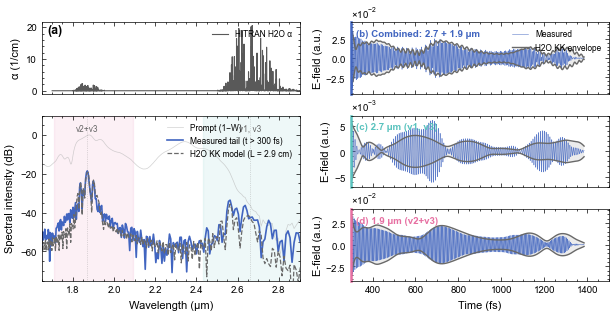

In [9]:
# =============================================================================
# FIGURE: HITRAN absorption + spectral comparison (left),
#         band-resolved FID in the time domain (right)
# =============================================================================
band_labels = [
    {'wl': 1.38, 'label': 'ν1+ν3'},
    {'wl': 1.87, 'label': 'ν2+ν3'},
    {'wl': 2.66, 'label': 'ν1, ν3'},
]

# One colour per band, used to cross-reference the spectral and time panels
band_colors = {'combined': cycle_colors[0], 2.7: cycle_colors[2], 1.9: cycle_colors[1]}
panel_label_kw = dict(fontsize=BIGGER_SIZE, fontweight='bold', va='top', ha='left')

fig = plt.figure(figsize=(16 * cm, 8 * cm))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1],
                      hspace=0.30, wspace=0.20,
                      left=0.08, right=0.98, top=0.95, bottom=0.13)

# ===== (a) top left: bare HITRAN absorption =====
ax_abs = fig.add_subplot(gs[0, 0])
ax_abs.plot(wl_ref_um, alpha_all, lw=0.8, color='0.35', label='HITRAN H2O α')
ax_abs.set_xlim(1.65, 2.9)
ax_abs.set_ylabel('α (1/cm)')
ax_abs.legend(fontsize=SMALL_SIZE - 1, loc='upper right', frameon=False)
ax_abs.tick_params(axis='x', labelbottom=False)
ax_abs.text(0.02, 0.97, '(a)', transform=ax_abs.transAxes, **panel_label_kw)

# ===== bottom left: spectral comparison, spanning the lower two rows =====
ax_sp = fig.add_subplot(gs[1:3, 0], sharex=ax_abs)

ax_sp.plot(wl_pr[mask_pr], spec_pr_dB[mask_pr],
           lw=0.5, color='0.70', alpha=0.6, label='Prompt (1−W)')
ax_sp.plot(wl_meas[mask_meas], spec_meas_dB[mask_meas],
           lw=def_linewidth, color=cycle_colors[0],
           label=f'Measured tail (t > {t_gate_fs} fs)')
ax_sp.plot(wl_sim[mask_sim], spec_sim_dB[mask_sim],
           lw=0.9, ls='--', color=cycle_colors[3],
           label=f'H2O KK model (L = {L_cm:.1f} cm)')

# Shade the bandpass windows
for wl_c in (1.9, 2.7):
    ax_sp.axvspan(wl_c * (1 - rel_bw), wl_c * (1 + rel_bw),
                  color=band_colors[wl_c], alpha=0.10, zorder=0)

for bl in band_labels:
    if 1.5 <= bl['wl'] <= 3.0:
        ax_sp.axvline(bl['wl'], color='grey', ls=':', lw=0.5, alpha=0.5)
        ax_sp.text(bl['wl'], 1, bl['label'], fontsize=SMALL_SIZE - 1,
                   color='0.4', ha='center', va='bottom')

ax_sp.set_xlim(1.65, 2.9)
ax_sp.set_ylim(-75, 10)
ax_sp.set_xlabel('Wavelength (µm)')
ax_sp.set_ylabel('Spectral intensity (dB)')
ax_sp.legend(fontsize=SMALL_SIZE - 1, loc='upper right', frameon=False)

# ===== (b-d) right: band-resolved FID, shared x-axis =====
panels_r = [
    (gs[0, 1], filt_meas_combined, filt_sim_combined,
     'Combined: 2.7 + 1.9 µm', '(b)', band_colors['combined']),
    (gs[1, 1], f_meas_27, f_sim_27,
     '2.7 µm (ν1, ν3)', '(c)', band_colors[2.7]),
    (gs[2, 1], f_meas_19, f_sim_19,
     '1.9 µm (ν2+ν3)', '(d)', band_colors[1.9]),
]

t_post = time_centered_n5 >= t_gate_fs
ax_right = []

for idx, (gspec, f_meas, f_sim, title, plbl, bclr) in enumerate(panels_r):
    ax = fig.add_subplot(gspec, sharex=ax_right[0] if ax_right else None)
    ax_right.append(ax)

    # The measurement stays an oscillating field; the model is shown as its
    # Hilbert envelope only, so the two do not overlap as look-alike fields.
    env_s = np.abs(hilbert_signal(np.real(f_sim)))

    ax.plot(time_centered_n5, np.real(f_meas), lw=0.4, color=cycle_colors[0],
            alpha=0.85, label='Measured' if idx == 0 else None)
    ax.fill_between(time_centered_n5, -env_s, env_s,
                    color=cycle_colors[3], alpha=0.12, lw=0)
    ax.plot(time_centered_n5, env_s, lw=1.0, color=cycle_colors[3],
            label='H2O KK envelope' if idx == 0 else None)
    ax.plot(time_centered_n5, -env_s, lw=1.0, color=cycle_colors[3])

    ax.set_xlim(t_gate_fs, 1500)

    # y-limits from the post-gate data only
    yvals = np.concatenate([np.real(f_meas[t_post]), env_s[t_post]])
    ax.set_ylim(-np.max(np.abs(yvals)) * 1.15, np.max(np.abs(yvals)) * 1.15)

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
    ax.set_ylabel('E-field (a.u.)', labelpad=2)
    ax.text(0.02, 0.90, f'{plbl} {title}', transform=ax.transAxes,
            fontsize=SMALL_SIZE, color=bclr, fontweight='bold', va='top')

    # Colour-coded left spine ties the panel to its band
    ax.spines['left'].set_color(bclr)
    ax.spines['left'].set_linewidth(1.8)

    if idx < 2:
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel('Time (fs)')

ax_right[0].legend(fontsize=SMALL_SIZE - 1, loc='upper right', frameon=False)

if saveplots:
    plt.savefig(f'{saveFigDir}fid_composite_h2o.pdf', dpi=300)
    plt.savefig(f'{saveFigDir}fid_composite_h2o.png', dpi=300)
plt.show()